# Multi-Spectrum Line Extraction

In this notebook, we'll demonstrate how to fit a batch of spectra simultaneously using Prism's `MultiFit` capabilities, and extract array-valued metrics across the dataset using both the model's built-in `.ew` attribute and Prism's advanced `SelectedLineCollection` tools.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.modeling.models import Polynomial1D
from prism.modeling.models.lines import GaussianLines
from prism.modeling.fitting import TRFLSQFitter
from prism.modeling.line_analysis import select_line
import prism.modeling.display

np.random.seed(42)

## 1. Creating the Data and the Base Model

Let's generate five synthetic spectra representing different spatial regions or time steps. We'll set up a base model consisting of a flat continuum and two emission lines: H$\beta$ and [O III].

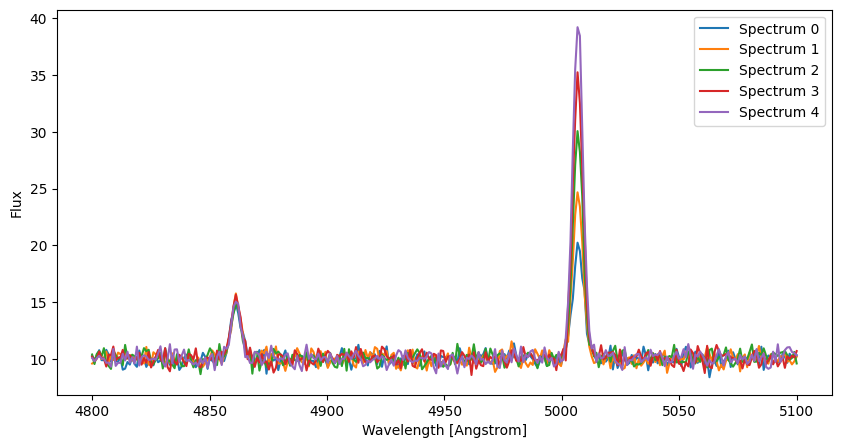

In [3]:
wave = np.linspace(4800, 5100, 300) * u.AA
nspectra = 5
spectra = np.zeros((nspectra, len(wave)))

cont = Polynomial1D(c0=10.0, degree=0, name='Continuum')
lines = GaussianLines.from_arrays(
    names=['Hb', 'OIII'],
    pos=[4861.333, 5006.843] * u.AA,
    fwhm=300.0,
    amp_hb=5.0,
    amp_oiii=10.0,
    name='Lines'
)
base_model = cont + lines

# Generate spectra with varying [O III] amplitude and some noise
plt.figure(figsize=(10, 5))
for i in range(nspectra):
    m = base_model.copy()
    m.right.amp_oiii.value = 10.0 + i * 5.0 # increasing OIII flux
    spectra[i] = m(wave) + np.random.normal(0, 0.5, size=len(wave))
    plt.plot(wave, spectra[i], label=f'Spectrum {i}')

plt.xlabel(f"Wavelength [{wave.unit}]")
plt.ylabel("Flux")
plt.legend()
plt.show()

## 2. Fitting the Batch

We can fit all five spectra simultaneously using `fitter.multifit()`. This parallelizes the fitting process across the dataset and returns a `MultiFitResult` which contains parameters stored as multi-dimensional arrays.

In [4]:
fitter = TRFLSQFitter()
# Assuming equal uncertainties of 0.5
yerr = np.full_like(spectra, 0.5)

# multifit automatically detects the batch dimension and parallelizes the fit
results = fitter.multifit(model=base_model, x=wave, y=spectra, yerr=yerr)

print(f"Fitted {results.n_spaxels} spectra.")
print(f"Array of OIII amplitudes:\n{results.amp_oiii_1.value}")

Fitting spectra:   0%|          | 0/5 [00:00<?, ?it/s]

Fitted 5 spectra.
Array of OIII amplitudes:
[ 9.83791818 14.69303155 19.98166161 24.70253025 29.71131493]


## 3. Extracting Equivalent Widths

Prism components retain their diagnostic methods even in a MultiFit context. The `ew()` method of the `Lines` component automatically returns a `Metric` containing arrays instead of scalar values. Since `GaussianLines` contains multiple lines, the returned `Metric` shape is `(nspectra, nlines)`.

In [13]:
results[0].model

<CompoundModel(Continuum + Lines; c0_0=9.97985, amp_hb_1=4.62762, amp_oiii_1=9.83792, offset_1=9.37652 km / s, ...)>

In [15]:
results.c0_0.value

array([ 9.97984801,  9.98969625, 10.05103703, 10.03867737, 10.04111712])

In [16]:
lines_comp = results.comps['Lines']
cont_comp = results.comps['Continuum']

# Calculate EW using the fitted continuum values
# We pass continuum=results.c0_0.value because it contains the array of continuum amplitudes
ew_results = lines_comp.ew(continuum=results.c0_0.value, method='constant-continuum')

print("Equivalent Width Metric shape:", np.asarray(ew_results.value).shape)
print("\nEquivalent Widths for H-beta (index 0):")
print(np.asarray(ew_results.value)[:, 0])
print("\nEquivalent Widths for [O III] (index 1):")
print(np.asarray(ew_results.value)[:, 1])

Equivalent Width Metric shape: (5, 2)

Equivalent Widths for H-beta (index 0):
[2.65322864 2.73639759 2.40542356 2.80798706 2.57779341]

Equivalent Widths for [O III] (index 1):
[ 5.80936452  7.85034788 10.4853624  13.36820801 16.07732958]


## 4. Advanced Line Analysis with `SelectedLineCollection`

We can use Prism's line selection tools to extract complex shape metrics (e.g. bisector span) across the entire dataset. `select_line` returns a `SelectedLineCollection` when called on a `MultiFitResult`.

First, we use `.measure()` to evaluate metrics directly from the best-fit profile.

In [17]:
# Select just the [O III] line
oiii_selection = select_line(results, 'OIII')
print("Selection:", oiii_selection)

# Measure shape metrics across the batch
measurements = oiii_selection.measure(x=wave)
print("\nBisector Span (array):\n", measurements.bisector_span)

Selection: SelectedLineCollection(selector='OIII', shape=(5,))

Bisector Span (array):
 [-0.02194044  0.01370337  0.01194748  0.00892859  0.0087946 ]


We can also propagate parameter uncertainties to these complex shape metrics. While `.sample()` doesn't automatically batch across the dataset, we can iterate through the collection to perform Monte Carlo sampling on each spectrum's best-fit parameters.

In [18]:
bisector_spans = []
bisector_span_stds = []

# Iterating over the collection yields a SelectedLineProfile for each spectrum
for profile in oiii_selection:
    # Sample the uncertainties of the shape metrics via Monte Carlo
    sampled_metrics = profile.sample(x=wave, n_samples=100, random_state=42)
    
    bisector_spans.append(sampled_metrics.bisector_span.value)
    bisector_span_stds.append(sampled_metrics.bisector_span.std)

print("Sampled Bisector Spans:", bisector_spans)
print("Sampled Bisector Span Uncertainties:", bisector_span_stds)

Sampled Bisector Spans: [-0.021940442882623756, 0.013703366435947828, 0.01194748206398799, 0.008928591589210555, 0.00879459823408979]
Sampled Bisector Span Uncertainties: [0.010736557254080308, 0.006367232979864091, 0.004206518111488946, 0.008332204701784947, 0.007580524157540163]
